In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [2]:
 DATA_DIR = "ml-1m"

In [3]:
# Users: userId, gender, age, occupation, zip
users = pd.read_csv(
    f"{DATA_DIR}/users.dat",
    sep="::",
    engine="python",
    header=None,
    names=["user_id", "gender", "age", "occupation", "zip"]
)
users.head()

,user_id,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117
3,4,M,45,7,02460
4,5,M,25,20,55455


In [4]:
# Movies: movieId, title, genres
movies = pd.read_csv(
    f"{DATA_DIR}/movies.dat",
    sep="::",
    engine="python",
    header=None,
    names=["movie_id", "title", "genres"],
    encoding="latin-1"
)
movies.head()

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
# Ratings: userId, movieId, rating, timestamp
ratings = pd.read_csv(
    f"{DATA_DIR}/ratings.dat",
    sep="::",
    engine="python",
    header=None,
    names=["user_id", "movie_id", "rating", "timestamp"]
)
ratings.head()

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [6]:
# MERGE DATA
df = ratings.merge(users, on="user_id")

In [7]:
df = df.merge(movies, on="movie_id")

In [8]:
print(df.shape)
df.head()

(1000209, 10)


,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres
0,1,1193,5,978300760,F,1,10,48067,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,My Fair Lady (1964),Musical|Romance
3,1,3408,4,978300275,F,1,10,48067,Erin Brockovich (2000),Drama
4,1,2355,5,978824291,F,1,10,48067,"Bug's Life, A (1998)",Animation|Children's|Comedy


## Exploratory Data Analysis

In [9]:
# Gender Distribution
users["gender"].value_counts()
users["gender"].value_counts(normalize=True)

gender
M    0.717053
F    0.282947
Name: proportion, dtype: float64

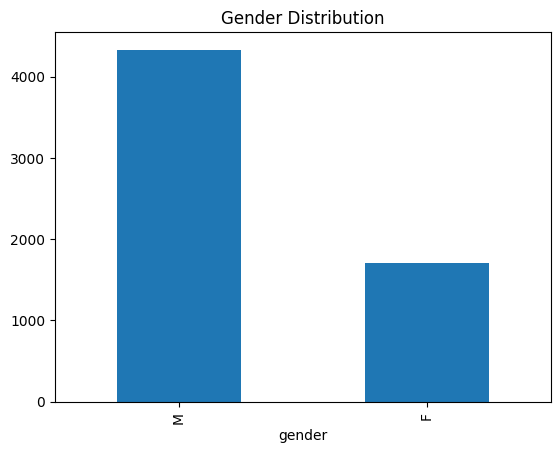

In [10]:
users["gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.savefig("plots/gender_distribution.png", bbox_inches="tight")
plt.show()

In [11]:
# Age Distribution

In [12]:
users["age"].value_counts().sort_index()

age
1      222
18    1103
25    2096
35    1193
45     550
50     496
56     380
Name: count, dtype: int64

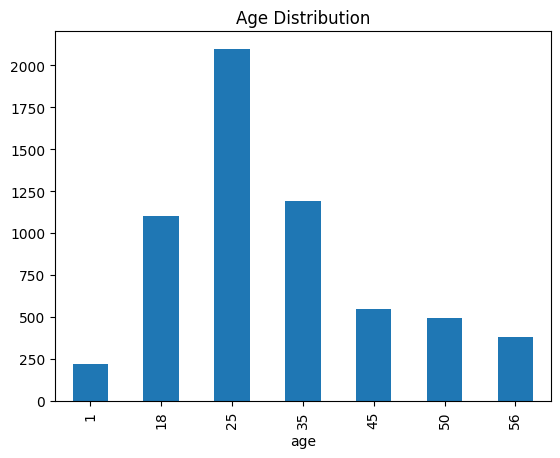

In [13]:
users["age"].value_counts().sort_index().plot(kind="bar")
plt.title("Age Distribution")
plt.savefig("plots/age_distribution.png", bbox_inches="tight")
plt.show()

In [14]:
# Ratings Distribution

In [15]:
ratings["rating"].value_counts().sort_index()

rating
1     56174
2    107557
3    261197
4    348971
5    226310
Name: count, dtype: int64

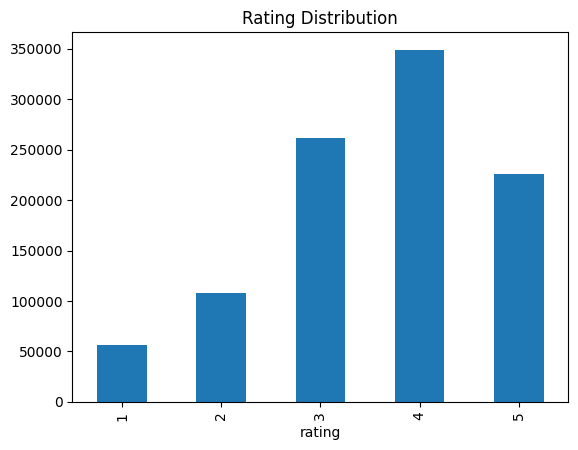

In [16]:
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.savefig("plots/rating_distribution.png", bbox_inches="tight")
plt.show()

In [17]:
# Ratings Per User

In [18]:
ratings_per_user = ratings.groupby("user_id").size()

print("Min ratings:", ratings_per_user.min())
print("Max ratings:", ratings_per_user.max())
print("Mean ratings:", ratings_per_user.mean())
print("Median ratings:", ratings_per_user.median())

Min ratings: 20
Max ratings: 2314
Mean ratings: 165.5975165562914
Median ratings: 96.0


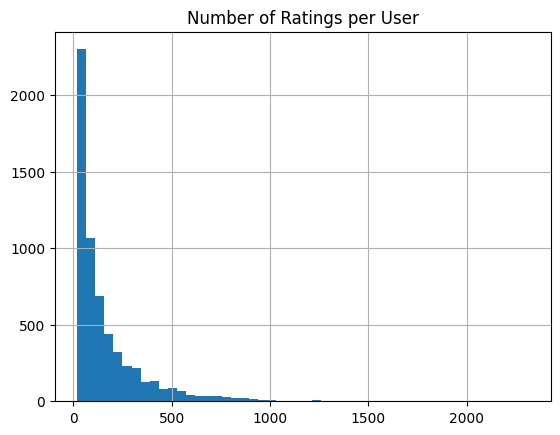

In [19]:
ratings_per_user.hist(bins=50)
plt.title("Number of Ratings per User")
plt.savefig("plots/number_of_rating_per_user.png", bbox_inches="tight")
plt.show()

In [20]:
# Ratings Per Movie

In [21]:
ratings_per_movie = ratings.groupby("movie_id").size()

print("Min ratings:", ratings_per_movie.min())
print("Max ratings:", ratings_per_movie.max())
print("Mean ratings:", ratings_per_movie.mean())
print("Median ratings:", ratings_per_movie.median())

Min ratings: 1
Max ratings: 3428
Mean ratings: 269.88909875876953
Median ratings: 123.5


In [22]:
# Gender vs Rating Behavior

In [23]:
df.groupby("gender")["rating"].mean()

gender
F    3.620366
M    3.568879
Name: rating, dtype: float64

In [24]:
df.groupby("gender")["rating"].count()

gender
F    246440
M    753769
Name: rating, dtype: int64

In [25]:
# Genre Exploration

In [26]:
movies["genres"].head()

0     Animation|Children's|Comedy
1    Adventure|Children's|Fantasy
2                  Comedy|Romance
3                    Comedy|Drama
4                          Comedy
Name: genres, dtype: str

In [27]:
genre_counter = Counter()

for g in movies["genres"]:
    for genre in g.split("|"):
        genre_counter[genre] += 1

genre_counter

Counter({'Drama': 1603,
         'Comedy': 1200,
         'Action': 503,
         'Thriller': 492,
         'Romance': 471,
         'Horror': 343,
         'Adventure': 283,
         'Sci-Fi': 276,
         "Children's": 251,
         'Crime': 211,
         'War': 143,
         'Documentary': 127,
         'Musical': 114,
         'Mystery': 106,
         'Animation': 105,
         'Fantasy': 68,
         'Western': 68,
         'Film-Noir': 44})

### Exploratory Data Analysis Summary

The dataset shows a noticeable **gender imbalance**: about **72% male** and **28% female** users. This means a naive classifier predicting “male” for everyone would already reach roughly **72% accuracy**, which is an important baseline when evaluating gender prediction models.

The **age distribution is uneven** as well. The largest group is **25–34**, while the youngest and oldest groups contain far fewer users. Smaller classes may therefore be harder to predict and may benefit from merging age groups later in the modeling phase.

Ratings are **strongly skewed toward positive values**. Most ratings are **3, 4, or 5**, while low ratings are relatively rare. This suggests that **what users choose to watch** may carry more information than the exact rating values themselves.

User activity varies a lot. Some users rated only **~20 movies**, while the most active users rated **over 2000**. This means some users provide much richer behavioral signals than others.

Genre distribution shows that **Drama and Comedy dominate the dataset**, followed by Action, Thriller, and Romance. Since movies can belong to multiple genres, genre information provides a useful basis for constructing **user preference features** in the future stage.

# Gender Prediction

In [28]:
# users as samples

In [29]:
# Aggregate basic statistics
user_features = ratings.groupby("user_id").agg(
    rating_count = ("rating", "count"),
    mean_rating = ("rating", "mean"),
    std_rating = ("rating", "std"),
)

In [30]:
# Percentage of 5-star ratings
five_star = ratings.assign(is_five = (ratings["rating"] == 5).astype(int))
five_star = five_star.groupby("user_id")["is_five"].mean()

In [31]:
# Percentage of 1-star ratings
one_star = ratings.assign(is_one = (ratings["rating"] == 1).astype(int))
one_star = one_star.groupby("user_id")["is_one"].mean()

In [32]:
# Add to feature table
user_features["pct_5"] = five_star
user_features["pct_1"] = one_star

user_features.head()

,rating_count,mean_rating,std_rating,pct_5,pct_1
user_id,,,,,
1,53,4.188679,0.680967,0.339623,0.000000
2,129,3.713178,1.001513,0.263566,0.015504
3,51,3.901961,0.984985,0.294118,0.019608
4,21,4.190476,1.077917,0.476190,0.047619
5,198,3.146465,1.132699,0.106061,0.095960


In [33]:
user_features = user_features.merge(
    users[["user_id", "gender"]],
    on="user_id"
)

user_features.head()

,user_id,rating_count,mean_rating,std_rating,pct_5,pct_1,gender
0,1,53,4.188679,0.680967,0.339623,0.000000,F
1,2,129,3.713178,1.001513,0.263566,0.015504,M
2,3,51,3.901961,0.984985,0.294118,0.019608,M
3,4,21,4.190476,1.077917,0.476190,0.047619,M
4,5,198,3.146465,1.132699,0.106061,0.095960,M


In [34]:
# convert gender to numeric
user_features["gender"] = user_features["gender"].map({"F": 0, "M": 1})

## Logistic Regression (baseline model)

In [35]:
X = user_features.drop(columns=["user_id", "gender"])
y = user_features["gender"]

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [37]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [38]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [39]:
print("Accuracy:", model.score(X_test_scaled, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))

Accuracy: 0.7168874172185431

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       342
           1       0.72      1.00      0.84       866

    accuracy                           0.72      1208
   macro avg       0.36      0.50      0.42      1208
weighted avg       0.51      0.72      0.60      1208

ROC-AUC: 0.5266770660291993


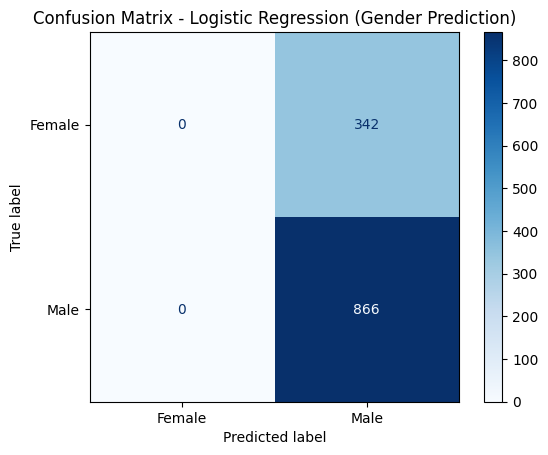

In [40]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Logistic Regression (Gender Prediction)")
plt.savefig("plots/lr_gender_1.png", bbox_inches="tight")
plt.show()

Model is predicting every user as male, which is why accuracy is ~0.72. Which is exactly the baseline classifier we discussed earlier

In [41]:
# We need genre information per rating.

In [42]:
# Merge ratings with movie genres
ratings_genres = ratings.merge(
    movies[["movie_id", "genres"]],
    on="movie_id"
)

ratings_genres.head()

,user_id,movie_id,rating,timestamp,genres
0,1,1193,5,978300760,Drama
1,1,661,3,978302109,Animation|Children's|Musical
2,1,914,3,978301968,Musical|Romance
3,1,3408,4,978300275,Drama
4,1,2355,5,978824291,Animation|Children's|Comedy


In [43]:
# Some movies have multiple genres separated by "|". We split them into separate rows.

# Split genres into list
ratings_genres["genres"] = ratings_genres["genres"].str.split("|")

# Explode
ratings_genres = ratings_genres.explode("genres")

ratings_genres.head()

,user_id,movie_id,rating,timestamp,genres
0,1,1193,5,978300760,Drama
1,1,661,3,978302109,Animation
1,1,661,3,978302109,Children's
1,1,661,3,978302109,Musical
2,1,914,3,978301968,Musical


In [44]:
# Genre Frequency Features (Count per User per Genre)

# Count how many times each user rated each genre
genre_counts = (
    ratings_genres
    .groupby(["user_id", "genres"])
    .size()
    .unstack(fill_value=0)
)

genre_counts.head()

genres,Action,Adventure,Animation,Children's,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
user_id,,,,,,,,,,,,,,,,,,
1,5,5,18,20,14,2,0,21,3,0,0,14,0,6,3,3,2,0
2,56,19,0,0,25,12,0,79,1,1,2,0,3,24,17,31,15,3
3,23,25,3,3,30,0,0,8,2,0,3,1,1,5,6,5,2,6
4,19,6,0,1,0,1,0,6,2,0,3,0,0,2,9,4,3,2
5,31,9,4,6,56,21,6,104,0,3,10,3,8,30,15,39,6,1


In [45]:
# Average rating per genre per user
genre_avg_rating = (
    ratings_genres
    .groupby(["user_id", "genres"])["rating"]
    .mean()
    .unstack(fill_value=0)
)

# Rename columns to distinguish them
genre_avg_rating = genre_avg_rating.add_prefix("avg_")

genre_avg_rating.head()

genres,avg_Action,avg_Adventure,avg_Animation,avg_Children's,avg_Comedy,avg_Crime,avg_Documentary,avg_Drama,avg_Fantasy,avg_Film-Noir,avg_Horror,avg_Musical,avg_Mystery,avg_Romance,avg_Sci-Fi,avg_Thriller,avg_War,avg_Western
user_id,,,,,,,,,,,,,,,,,,
1,4.200000,4.000000,4.111111,4.250000,4.142857,4.000000,0.000000,4.428571,4.0,0.0,0.000000,4.285714,0.000000,3.666667,4.333333,3.666667,5.000000,0.000000
2,3.500000,3.736842,0.000000,0.000000,3.560000,3.583333,0.000000,3.898734,3.0,4.0,3.000000,0.000000,3.333333,3.708333,3.588235,3.483871,3.733333,4.333333
3,3.956522,4.000000,4.000000,4.000000,3.766667,0.000000,0.000000,4.000000,4.5,0.0,2.666667,4.000000,3.000000,3.800000,3.833333,3.800000,4.000000,4.666667
4,4.157895,3.833333,0.000000,4.000000,0.000000,5.000000,0.000000,4.166667,4.5,0.0,4.333333,0.000000,0.000000,4.000000,3.555556,3.500000,3.333333,4.500000
5,2.612903,3.000000,4.000000,3.833333,3.410714,3.285714,3.666667,3.096154,0.0,4.0,2.800000,3.333333,3.125000,3.100000,3.066667,2.846154,3.500000,4.000000


In [46]:
# Now merge genre features:

# Merge counts
user_features = user_features.merge(
    genre_counts,
    on="user_id"
)

# Merge averages
user_features = user_features.merge(
    genre_avg_rating,
    on="user_id"
)

user_features.head()

,user_id,rating_count,mean_rating,std_rating,pct_5,pct_1,gender,Action,Adventure,Animation,...,avg_Fantasy,avg_Film-Noir,avg_Horror,avg_Musical,avg_Mystery,avg_Romance,avg_Sci-Fi,avg_Thriller,avg_War,avg_Western
0,1,53,4.188679,0.680967,0.339623,0.000000,0,5,5,18,...,4.0,0.0,0.000000,4.285714,0.000000,3.666667,4.333333,3.666667,5.000000,0.000000
1,2,129,3.713178,1.001513,0.263566,0.015504,1,56,19,0,...,3.0,4.0,3.000000,0.000000,3.333333,3.708333,3.588235,3.483871,3.733333,4.333333
2,3,51,3.901961,0.984985,0.294118,0.019608,1,23,25,3,...,4.5,0.0,2.666667,4.000000,3.000000,3.800000,3.833333,3.800000,4.000000,4.666667
3,4,21,4.190476,1.077917,0.476190,0.047619,1,19,6,0,...,4.5,0.0,4.333333,0.000000,0.000000,4.000000,3.555556,3.500000,3.333333,4.500000
4,5,198,3.146465,1.132699,0.106061,0.095960,1,31,9,4,...,0.0,4.0,2.800000,3.333333,3.125000,3.100000,3.066667,2.846154,3.500000,4.000000


In [47]:
# logistic regression, but now with genre features

In [48]:
X = user_features.drop(columns=["user_id", "gender"])
y = user_features["gender"]

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [50]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [51]:
model = LogisticRegression()

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [52]:
print("Accuracy:", model.score(X_test_scaled, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))

Accuracy: 0.7822847682119205

Classification Report:

              precision    recall  f1-score   support

           0       0.70      0.41      0.52       342
           1       0.80      0.93      0.86       866

    accuracy                           0.78      1208
   macro avg       0.75      0.67      0.69      1208
weighted avg       0.77      0.78      0.76      1208

ROC-AUC: 0.8096747835717084


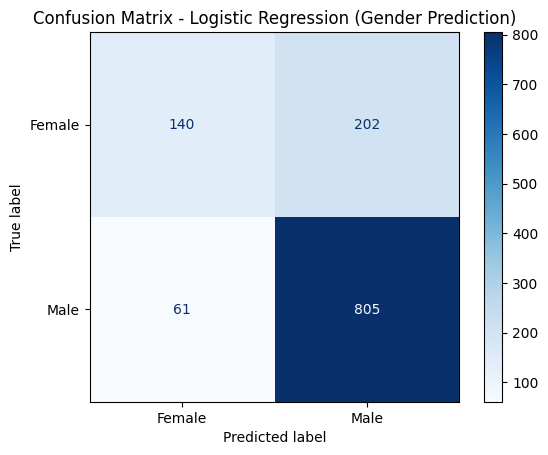

In [53]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Female", "Male"])
disp.plot(cmap="Blues", values_format="d")

plt.title("Confusion Matrix - Logistic Regression (Gender Prediction)")
plt.savefig("plots/lr_gender_2.png", bbox_inches="tight")
plt.show()

### Logistic Regression Summary

We first trained a logistic regression model using only basic rating statistics (rating count, mean rating, variance, extreme rating shares). The model achieved ~0.72 accuracy, but this mostly reflects the dataset’s gender imbalance — it largely predicts the majority class (male).

Adding genre-based features (genre rating counts and average ratings per genre) significantly improves performance.

• Accuracy increases to ~0.78

• ROC-AUC ≈ 0.81, indicating good class separation

• The model now correctly identifies a portion of female users instead of predicting almost all users as male

This suggests that genre preferences carry much stronger demographic signal than simple rating statistics.

In [54]:
feature_names = X.columns
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})

coef_df = coef_df.sort_values(by="coefficient", ascending=False)

coef_df.head(15)      # Most male-associated

,feature,coefficient
0,rating_count,0.962804
21,War,0.920025
5,Action,0.516234
9,Comedy,0.452907
19,Sci-Fi,0.440773
10,Crime,0.406973
7,Animation,0.349173
22,Western,0.296504
32,avg_Film-Noir,0.152191
33,avg_Horror,0.150832


In [55]:
coef_df.tail(15)      # Most female-associated

,feature,coefficient
2,std_rating,-0.054483
15,Horror,-0.069274
3,pct_5,-0.080507
6,Adventure,-0.081839
1,mean_rating,-0.133880
26,avg_Children's,-0.144984
13,Fantasy,-0.171155
17,Mystery,-0.181506
34,avg_Musical,-0.182415
36,avg_Romance,-0.233620


#### Coefficient Interpretation

Logistic regression coefficients give a rough indication of which viewing patterns are associated with each gender.

Features with **positive coefficients** push the prediction toward **male**, while **negative coefficients** push it toward **female**.

Some clear patterns appear:

- Higher **rating activity** (rating_count) is strongly associated with male users.

- Genres such as **War, Action, Sci-Fi, and Crime** tend to correlate with male predictions.

- Genres like **Romance, Children's, Drama, and Musical** are more associated with female predictions.

These patterns should not be interpreted as strict rules, but they suggest that **genre preferences contain meaningful demographic signals**, which explains why adding genre features improved the model performance.


## Random Forest

In [56]:
rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=12,
    min_samples_leaf=10,
    min_samples_split=20,
    max_features=0.5,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [57]:
print("Accuracy:", rf.score(X_test, y_test))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

Accuracy: 0.7607615894039735

Classification Report:

              precision    recall  f1-score   support

           0       0.58      0.59      0.58       342
           1       0.84      0.83      0.83       866

    accuracy                           0.76      1208
   macro avg       0.71      0.71      0.71      1208
weighted avg       0.76      0.76      0.76      1208

ROC-AUC: 0.8024391232121875


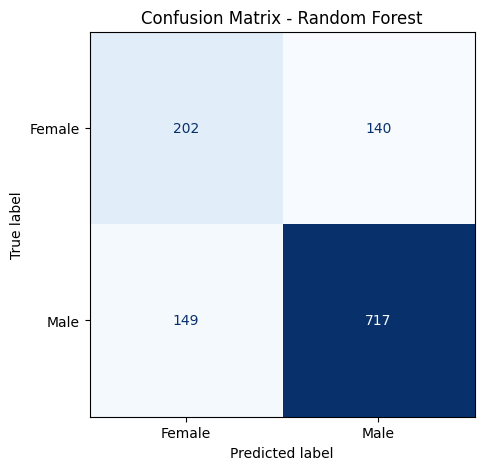

In [58]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Female", "Male"]
)
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.savefig("plots/rf_gender.png", bbox_inches="tight")
plt.show()

In [59]:
importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(15)

,feature,importance
18,Romance,0.152070
5,Action,0.108834
19,Sci-Fi,0.092493
21,War,0.038593
16,Musical,0.026115
26,avg_Children's,0.025535
34,avg_Musical,0.024393
9,Comedy,0.023314
10,Crime,0.022445
36,avg_Romance,0.022295


## Gender Prediction Summary

We model gender prediction as a binary classification problem based on user rating behavior. A first logistic regression model using only basic rating statistics achieved about **0.72 accuracy**, but this mostly reflects the dataset’s gender imbalance, as the model simply always predict the majority class (male).

Adding **genre-based features**—how often users rate each genre and their average rating within genres—improves performance to **~0.78 accuracy** and **~0.81 ROC-AUC**. The model also begins to identify female users more reliably, suggesting that **genre preferences contain useful demographic signal**. Coefficient inspection indicates that genres like **Action, War, and Sci-Fi** are more associated with male predictions, while **Romance, Children’s, and Drama** tend to correlate more with female users.

A **Random Forest** model trained on the same features achieves similar overall performance (~0.76 accuracy, ~0.80 ROC-AUC), but it provides **noticeably better recall for female users**, indicating a better balance between the classes. Feature importance also highlights genre preferences as the key predictors, with **Romance and Action appearing as the two most important features**, which is a somewhat funny but intuitive result given common stereotypes about movie tastes.

# Age Prediction

In [60]:
# Add Age to the Feature Table

user_features = user_features.merge(
    users[["user_id", "age"]],
    on="user_id"
)

In [61]:
user_features[["user_id", "age"]].head()

,user_id,age
0,1,1
1,2,56
2,3,25
3,4,45
4,5,25


In [62]:
user_features["age"].value_counts().sort_index()

age
1      222
18    1103
25    2096
35    1193
45     550
50     496
56     380
Name: count, dtype: int64

In [63]:
# merger 1 with 18 and 50 with 56

def map_age(age):
    if age in [1, 18]:
        return "under_25"
    elif age == 25:
        return "25_34"
    elif age == 35:
        return "35_44"
    elif age == 45:
        return "45_49"
    else:  # 50 or 56
        return "50_plus"

user_features["age_group"] = user_features["age"].apply(map_age)

In [64]:
user_features["age_group"].value_counts()

age_group
25_34       2096
under_25    1325
35_44       1193
50_plus      876
45_49        550
Name: count, dtype: int64

In [65]:
# Prepare Features for Modeling

In [66]:
X = user_features.drop(columns=["user_id", "gender", "age", "age_group"])
y_age = user_features["age_group"]

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_age,
    test_size=0.2,
    random_state=42,
    stratify=y_age
)

In [68]:
# BASELINE MODEL

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_age = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model_age.fit(X_train_scaled, y_train)

y_pred = model_age.predict(X_test_scaled)

In [69]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3435430463576159
              precision    recall  f1-score   support

       25_34       0.51      0.28      0.36       419
       35_44       0.26      0.19      0.22       239
       45_49       0.13      0.24      0.17       110
     50_plus       0.34      0.48      0.40       175
    under_25       0.40      0.54      0.46       265

    accuracy                           0.34      1208
   macro avg       0.33      0.35      0.32      1208
weighted avg       0.38      0.34      0.34      1208



In [70]:
# Add gender as a feature
X = user_features.drop(columns=["user_id", "age", "age_group"])
y_age = user_features["age_group"]

## Logistic Regression

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_age,
    test_size=0.2,
    random_state=42,
    stratify=y_age
)

In [72]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_age = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model_age.fit(X_train_scaled, y_train)

y_pred = model_age.predict(X_test_scaled)

In [73]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.34188741721854304
              precision    recall  f1-score   support

       25_34       0.52      0.27      0.36       419
       35_44       0.26      0.18      0.21       239
       45_49       0.15      0.28      0.19       110
     50_plus       0.32      0.46      0.38       175
    under_25       0.40      0.54      0.46       265

    accuracy                           0.34      1208
   macro avg       0.33      0.35      0.32      1208
weighted avg       0.38      0.34      0.34      1208



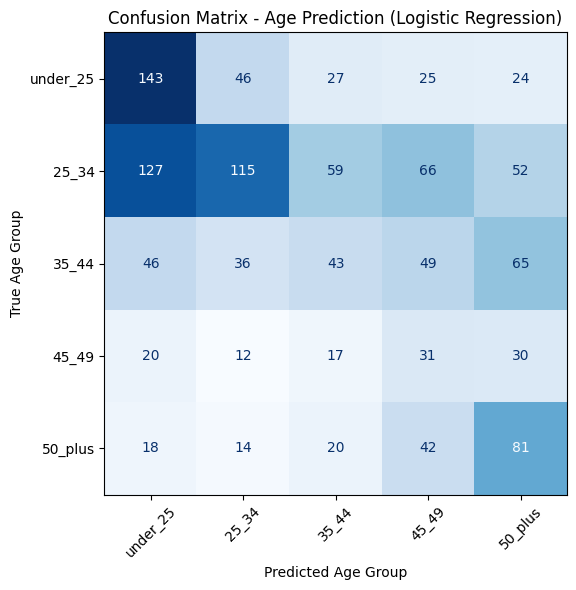

In [74]:
labels = ["under_25", "25_34", "35_44", "45_49", "50_plus"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - Age Prediction (Logistic Regression)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")

plt.tight_layout()
plt.savefig("plots/lr_age5class_1.png", bbox_inches="tight")
plt.show()

### Age Prediction – Baseline Summary

Age prediction is a multi-class classification problem, so to make the task more stable, the original MovieLens age categories were merged into five groups: under_25, 25_34, 35_44, 45_49, and 50_plus. Using the same feature set as before (rating statistics and genre-based features), we train a logistic regression baseline with class balancing.

Overall accuracy is ~0.34. With five classes, random guessing would yield about 0.20 accuracy, so the model clearly captures some real signal from user preferences, even though the task is substantially harder than gender prediction.

Performance is strongest for under_25 and 50_plus. These groups likely have more distinctive viewing patterns. These clearer behavioral differences make the extreme age groups easier for the model to identify.

The middle age groups (25_34, 35_44, 45_49) are much harder to distinguish. Their viewing patterns overlap heavily, both with each other and with the neighboring groups, which leads to lower precision and recall. In practice, movie preferences tend to change gradually with age rather than shifting abruptly between these categories, making strict class boundaries difficult for the model to learn.

Including gender as an additional feature does not noticeably change the results (accuracy remains ~0.34). This suggests that gender does not have a strong linear relationship with the age groups in this setup, at least within the logistic regression model.

## Random Forest and SVM for Age Prediction

In [75]:
rf_age = RandomForestClassifier(
    n_estimators=800,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_age.fit(X_train, y_train)

y_pred = rf_age.predict(X_test)

In [76]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.35596026490066224
              precision    recall  f1-score   support

       25_34       0.43      0.42      0.43       419
       35_44       0.26      0.16      0.20       239
       45_49       0.15      0.05      0.08       110
     50_plus       0.33      0.50      0.40       175
    under_25       0.36      0.45      0.40       265

    accuracy                           0.36      1208
   macro avg       0.30      0.32      0.30      1208
weighted avg       0.34      0.36      0.34      1208



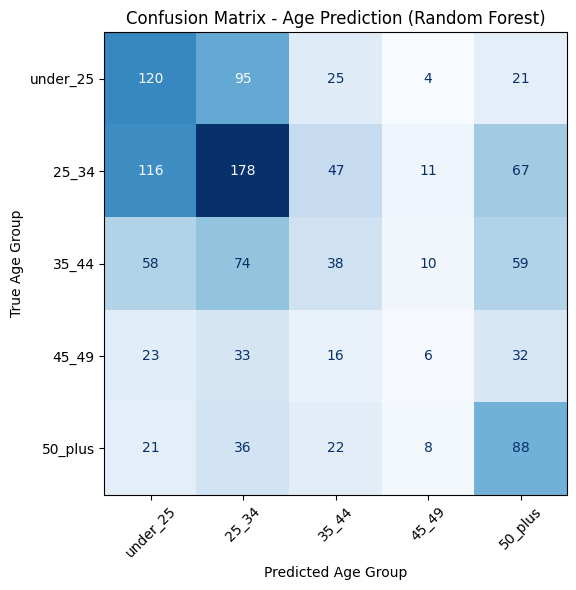

In [77]:
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - Age Prediction (Random Forest)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")

plt.tight_layout()
plt.savefig("plots/rf_age5class_1.png", bbox_inches="tight")
plt.show()

In [78]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_age.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
2,std_rating,0.044446
4,pct_1,0.034500
8,Animation,0.030530
20,Sci-Fi,0.029871
10,Comedy,0.028983
37,avg_Romance,0.028854
6,Action,0.028685
13,Drama,0.027899
1,mean_rating,0.027416
3,pct_5,0.027356


In [79]:
svm_age = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

svm_age.fit(X_train_scaled, y_train)

y_pred = svm_age.predict(X_test_scaled)

In [80]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3485099337748344
              precision    recall  f1-score   support

       25_34       0.50      0.27      0.35       419
       35_44       0.31      0.29      0.30       239
       45_49       0.15      0.26      0.19       110
     50_plus       0.32      0.41      0.35       175
    under_25       0.42      0.52      0.46       265

    accuracy                           0.35      1208
   macro avg       0.34      0.35      0.33      1208
weighted avg       0.38      0.35      0.35      1208



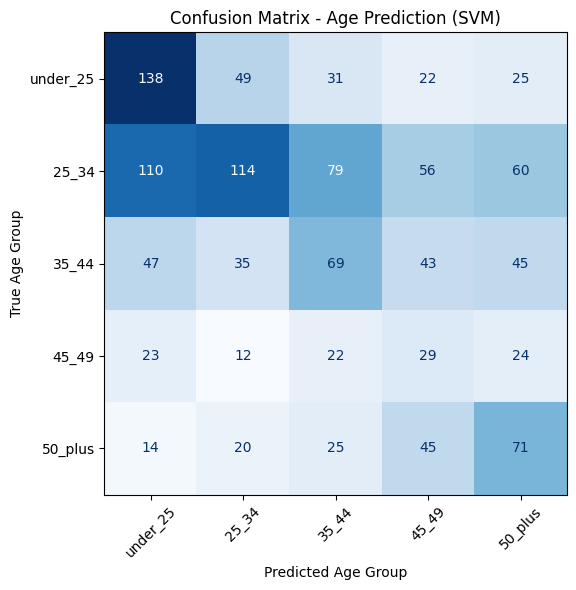

In [81]:
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - Age Prediction (SVM)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")

plt.tight_layout()
plt.savefig("plots/svm_age5class_1.png", bbox_inches="tight")
plt.show()

### Random Forest and SVM Results

We now tested **Random Forest** and **SVM (RBF kernel)** for age prediction. Both models produce results very similar to logistic regression, with accuracies around **0.35–0.36**. The overall pattern remains the same: **under_25** and **50_plus** are predicted relatively well, while the **middle age groups are difficult to distinguish**.

Since three different model types show nearly identical behavior, the main limitation appears to be the **overlap between the middle age categories**, rather than the model choice itself. For this reason, the next step is to **simplify the task by merging the middle groups**, reducing the problem to **three broader age classes**.

## Reducing number of classes to 3

In [82]:
# merge middle age

def map_age_3(age):
    if age in [1, 18]:
        return "under_25"
    elif age in [25, 35]:
        return "25_44"
    else:
        return "45_plus"

user_features["age_group_3"] = user_features["age"].apply(map_age_3)

In [83]:
user_features["age_group_3"].value_counts()

age_group_3
25_44       3289
45_plus     1426
under_25    1325
Name: count, dtype: int64

In [84]:
X = user_features.drop(columns=["user_id", "age", "age_group", "age_group_3"])
y = user_features["age_group_3"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [85]:
# linear regression

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_age = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

model_age.fit(X_train_scaled, y_train)

y_pred = model_age.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.45364238410596025
              precision    recall  f1-score   support

       25_44       0.65      0.32      0.43       658
     45_plus       0.42      0.65      0.51       285
    under_25       0.34      0.58      0.43       265

    accuracy                           0.45      1208
   macro avg       0.47      0.52      0.46      1208
weighted avg       0.53      0.45      0.45      1208



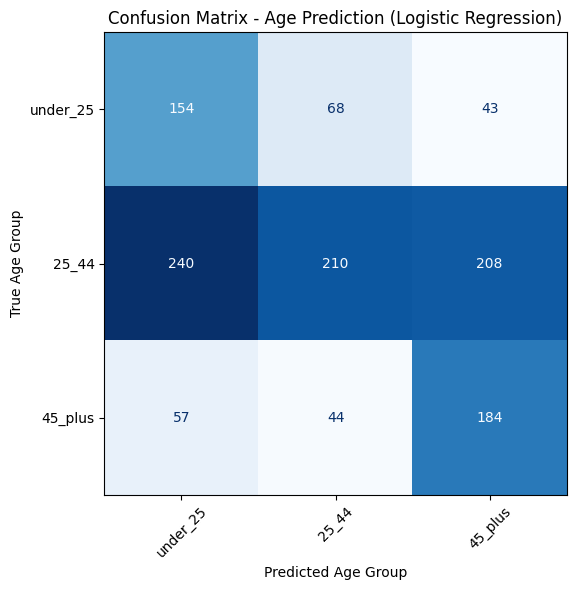

In [86]:
labels = ["under_25", "25_44", "45_plus"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - Age Prediction (Logistic Regression)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")

plt.tight_layout()
plt.savefig("plots/lr_age3class_1.png", bbox_inches="tight")
plt.show()

In [87]:
svm_age = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced"
)

svm_age.fit(X_train_scaled, y_train)

y_pred = svm_age.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.4693708609271523
              precision    recall  f1-score   support

       25_44       0.63      0.37      0.47       658
     45_plus       0.43      0.61      0.51       285
    under_25       0.35      0.56      0.43       265

    accuracy                           0.47      1208
   macro avg       0.47      0.51      0.47      1208
weighted avg       0.52      0.47      0.47      1208



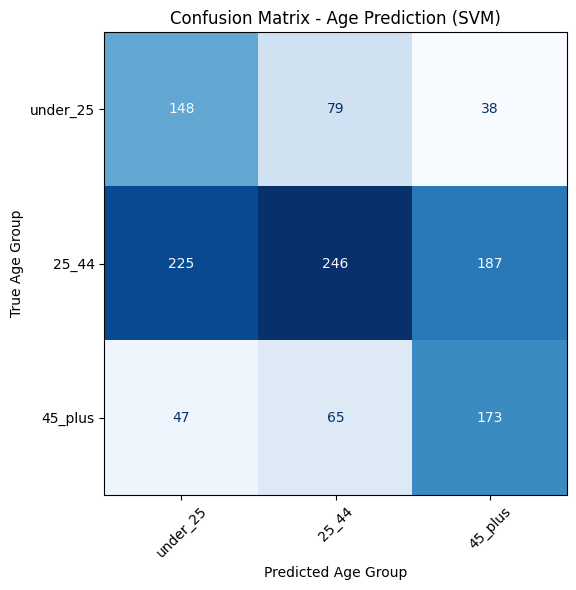

In [88]:
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - Age Prediction (SVM)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")

plt.tight_layout()
plt.savefig("plots/svm_age3class_1.png", bbox_inches="tight")
plt.show()

In [89]:
rf_age = RandomForestClassifier(
    n_estimators=800,
    max_depth=12,
    min_samples_leaf=5,
    min_samples_split=10,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_age.fit(X_train, y_train)

y_pred = rf_age.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5447019867549668
              precision    recall  f1-score   support

       25_44       0.60      0.69      0.65       658
     45_plus       0.51      0.38      0.43       285
    under_25       0.39      0.35      0.37       265

    accuracy                           0.54      1208
   macro avg       0.50      0.47      0.48      1208
weighted avg       0.53      0.54      0.54      1208



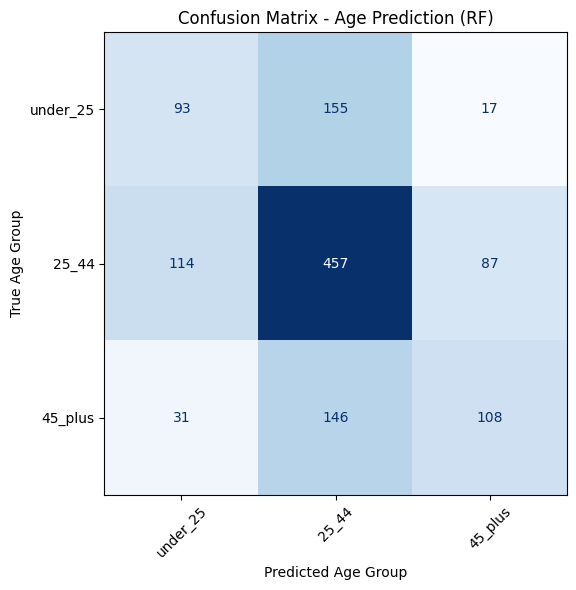

In [90]:
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
)

disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=False)

plt.title("Confusion Matrix - Age Prediction (RF)")
plt.xlabel("Predicted Age Group")
plt.ylabel("True Age Group")

plt.tight_layout()
plt.savefig("plots/rf_age3class_1.png", bbox_inches="tight")
plt.show()

In [91]:
feat_imp = pd.DataFrame({
    "feature": X.columns,
    "importance": rf_age.feature_importances_
}).sort_values("importance", ascending=False)

feat_imp.head(15)

,feature,importance
2,std_rating,0.052921
8,Animation,0.039032
4,pct_1,0.036696
23,Western,0.032385
20,Sci-Fi,0.031676
41,avg_Western,0.031308
26,avg_Animation,0.029846
6,Action,0.029663
37,avg_Romance,0.028135
10,Comedy,0.027842


### Age Prediction Summary

After reducing the task to **three age groups** (`under_25`, `25_44`, `45_plus`), performance improves noticeably. Logistic regression and SVM reach around **0.46–0.47 accuracy**, while **Random Forest performs best with ~0.55 accuracy**. Compared to the earlier five-class setup (~0.34–0.36), this confirms that most of the difficulty came from trying to separate very similar middle age categories.

The confusion matrices show a consistent pattern across models. The **25–44** group acts as a kind of default prediction, which is expected since it is the largest class. Both younger and older users are often predicted as middle-aged, indicating that their behavior overlaps substantially with the middle group.

The feature importance results from Random Forest show that no single genre dominates the prediction. Instead, the model relies on a mix of rating behavior (especially `std_rating`) and several genre indicators such as **Animation**, **Sci-Fi**, **Western**, and **Children’s**.

Overall, the final results suggest that **movie preferences contain some age-related signal**, but it is relatively coarse. The models are much better at distinguishing **broad generational groups** than precise age brackets. This aligns with intuition: people of similar ages often share cultural exposure and genre preferences, but these patterns change gradually over time rather than forming sharply separated categories.

## Project Summary (so far) and Next Step

So far we explored whether **user demographics can be inferred from movie rating behavior** using relatively simple, interpretable features. Users were represented with **rating statistics and genre-based features** (how often they rate each genre and their average ratings within genres), and several standard classifiers were tested.

For **gender prediction**, the results were fairly strong. Once genre features were added, models reached around **0.78 accuracy and ~0.81 ROC-AUC**, showing that genre preferences contain clear demographic signal. The patterns were also intuitive: genres such as **Action, War, and Sci-Fi** tended to correlate with male users, while **Romance, Drama, and Children’s movies** were more associated with female users.

For **age prediction**, the signal turned out to be weaker. With five age groups, all models performed similarly (~0.34–0.36 accuracy), suggesting strong overlap between the middle age categories. After simplifying the task to **three broader age groups**, performance improved, with **Random Forest reaching ~0.60 accuracy**. This indicates that movie preferences contain some age information, but mostly at the level of **broad generational differences** rather than precise age brackets.

Overall, the results show that **genre-based features already capture a meaningful part of the behavioral signal**, especially for gender prediction. However, this representation is still quite limited: it relies on **handcrafted genre categories** and treats each genre independently. It cannot capture more subtle structures in the rating data, such as relationships between movies that share similar audiences but not necessarily the same genre labels.

This motivates the next stage of the project: learning **latent representations directly from the rating matrix** using **matrix factorization / collaborative filtering**. Instead of predefined genres, we can derive **user and movie latent factors** that represent hidden preference dimensions discovered from the data itself. These embeddings may capture deeper patterns in viewing behavior and potentially provide **better features for demographic prediction** than the simple genre-based approach used so far.


In [92]:
X_train.columns

Index(['rating_count', 'mean_rating', 'std_rating', 'pct_5', 'pct_1', 'gender',
       'Action', 'Adventure', 'Animation', 'Children's', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical',
       'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'avg_Action', 'avg_Adventure', 'avg_Animation', 'avg_Children's',
       'avg_Comedy', 'avg_Crime', 'avg_Documentary', 'avg_Drama',
       'avg_Fantasy', 'avg_Film-Noir', 'avg_Horror', 'avg_Musical',
       'avg_Mystery', 'avg_Romance', 'avg_Sci-Fi', 'avg_Thriller', 'avg_War',
       'avg_Western'],
      dtype='str')